# 03. Control Points and Deseasonalization

Sentinel-2 RTS values drift over time even with no human activity present
(seasonal changes in soil moisture, sun angle, etc.). This notebook defines
a set of control points on open playa, far from the Black Rock City
footprint, and uses their RTS to estimate that natural drift so it can be
subtracted from the city points in later notebooks.


## Setup

This notebook is self-contained: it re-runs Drive mounting, imports, GEE
auth, and (if needed) DINOv2 loading, so it can be run on its own without
depending on any other notebook having been run first in the same session.
Cached patches/rasters from other notebooks are still reused automatically
via the shared `CACHE_DIR`.


In [1]:
from google.colab import drive
drive.mount("/content/drive")

import os
CACHE_DIR = "/content/drive/MyDrive/burning_man_cache/patch_cache"
os.makedirs(CACHE_DIR, exist_ok=True)


Mounted at /content/drive


In [2]:
import sys
sys.path.append("/content/drive/MyDrive/burning_man_repo")

from src.gee_utils import get_patch, get_patch_cached, fetch_bulk_raster_cached
from src.features import patch_to_pil, extract_feature, extract_patch_tokens, cosine_distance, compute_patch_heatmap


In [3]:
import ee
from config import GEE_PROJECT_ID

ee.Authenticate()
ee.Initialize(project=GEE_PROJECT_ID)


In [4]:
BASELINE_START, BASELINE_END = "2023-08-01", "2023-08-20"
EVENT_START, EVENT_END = "2023-10-05", "2023-10-18"
LATE_START, LATE_END = "2023-11-01", "2023-11-20"

WINDOWS = {
    "baseline": (BASELINE_START, BASELINE_END),
    "pei_period": (EVENT_START, EVENT_END),
    "late": (LATE_START, LATE_END),
}


In [5]:
!pip install transformers torch --quiet

import torch
from transformers import AutoImageProcessor, AutoModel

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

model_name = "facebook/dinov2-base"
processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)
model.eval()


Using device: cpu


/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Dinov2Model(
  (embeddings): Dinov2Embeddings(
    (patch_embeddings): Dinov2PatchEmbeddings(
      (projection): Conv2d(3, 768, kernel_size=(14, 14), stride=(14, 14))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): Dinov2Encoder(
    (layer): ModuleList(
      (0-11): 12 x Dinov2Layer(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attention): Dinov2Attention(
          (attention): Dinov2SelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
          )
          (output): Dinov2SelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (layer_scale1): Dinov2LayerScale()
        (drop_path): Identity()
        (norm2): LayerNorm((768,), eps=1e-06,

## Define candidate control points

10 candidates: 4 from the original selection, 6 added later to increase
sample size. All chosen to sit on flat open playa, away from the BRC
footprint and away from the mountain ranges at the edges of the playa
(which can introduce shadow/terrain artifacts).


In [6]:
import pandas as pd

control_points = pd.DataFrame([
    {"site_id": "CTRL_north_10km", "lat": 40.876, "lon": -119.206},
    {"site_id": "CTRL_north_20km", "lat": 40.966, "lon": -119.206},
    {"site_id": "CTRL_east_8km",   "lat": 40.786, "lon": -119.106},
    {"site_id": "CTRL_west_8km",   "lat": 40.786, "lon": -119.306},
])

additional_control_points = pd.DataFrame([
    {"site_id": "CTRL_north_5km",      "lat": 40.831, "lon": -119.206},
    {"site_id": "CTRL_north_15km",     "lat": 40.921, "lon": -119.206},
    {"site_id": "CTRL_east_15km",      "lat": 40.786, "lon": -119.027},
    {"site_id": "CTRL_west_15km",      "lat": 40.786, "lon": -119.385},
    {"site_id": "CTRL_northeast_10km", "lat": 40.850, "lon": -119.122},
    {"site_id": "CTRL_northwest_10km", "lat": 40.850, "lon": -119.290},
])

all_control_points = pd.concat([control_points, additional_control_points], ignore_index=True)
all_control_points


,site_id,lat,lon
0,CTRL_north_10km,40.876,-119.206
1,CTRL_north_20km,40.966,-119.206
2,CTRL_east_8km,40.786,-119.106
3,CTRL_west_8km,40.786,-119.306
4,CTRL_north_5km,40.831,-119.206
5,CTRL_north_15km,40.921,-119.206
6,CTRL_east_15km,40.786,-119.027
7,CTRL_west_15km,40.786,-119.385
8,CTRL_northeast_10km,40.850,-119.122
9,CTRL_northwest_10km,40.850,-119.290


## Visual sanity check

A control point is only usable if its baseline image shows uniform, flat
open-desert reflectance — not vegetation, not water/wet playa, and not an
empty/black patch (which usually means the requested region fell outside
the available image's coverage rather than reflecting real ground content).


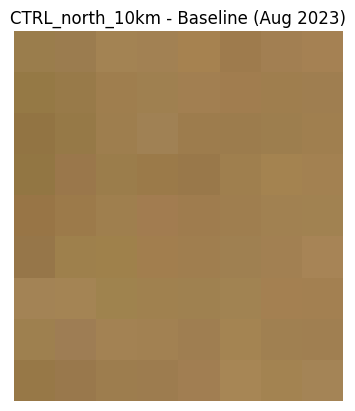

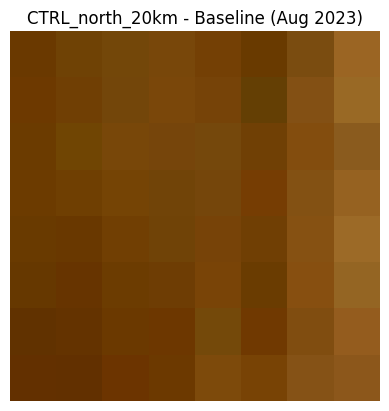

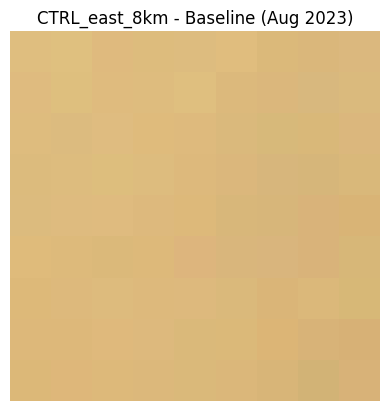

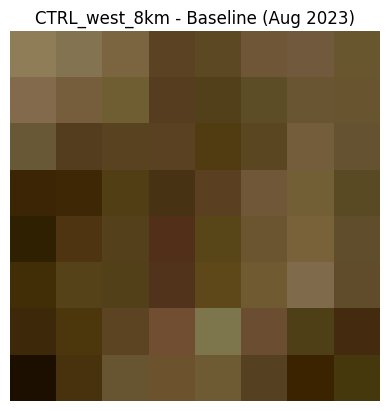

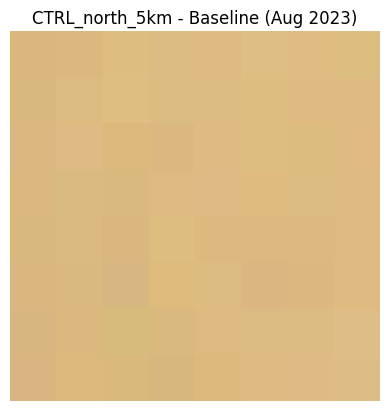

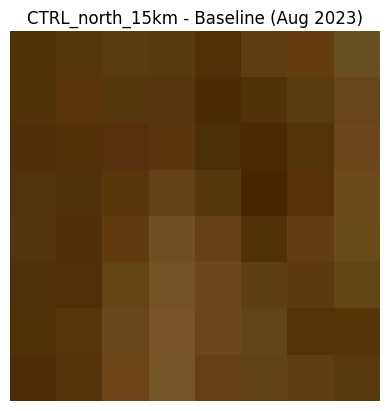

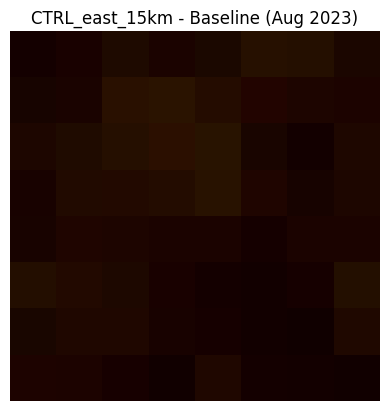

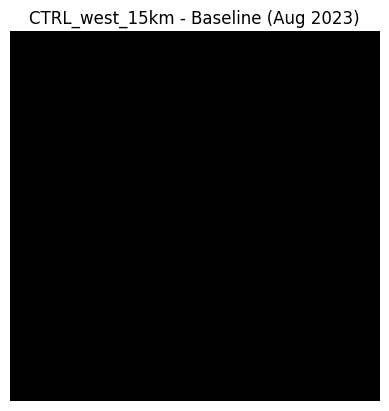

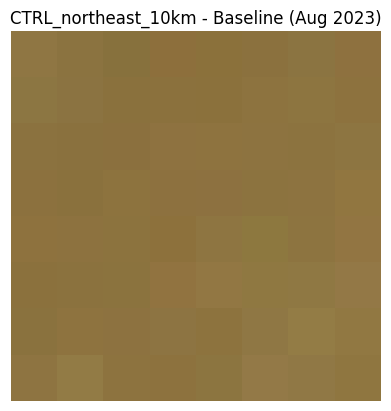

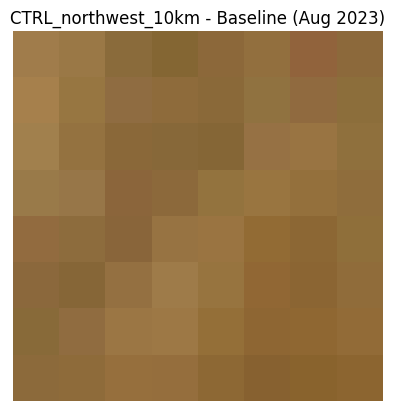

In [7]:
import numpy as np
import matplotlib.pyplot as plt

STRETCH_MIN = 2000
STRETCH_MAX = 5500

def show_rgb(patch, title=""):
    if patch is None:
        print(f"No image available for: {title}")
        return
    rgb = patch[:, :, [2, 1, 0]]  # B4, B3, B2
    rgb_stretched = np.clip((rgb - STRETCH_MIN) / (STRETCH_MAX - STRETCH_MIN), 0, 1)
    plt.imshow(rgb_stretched)
    plt.title(title)
    plt.axis("off")
    plt.show()

control_baseline_patches = {}
for _, row in all_control_points.iterrows():
    patch = get_patch_cached(CACHE_DIR, row["site_id"], "baseline", row["lat"], row["lon"], *WINDOWS["baseline"])
    control_baseline_patches[row["site_id"]] = patch
    show_rgb(patch, f"{row['site_id']} - Baseline (Aug 2023)")


## Result of the visual check

`CTRL_east_15km` and `CTRL_west_15km` come back as solid black — almost
certainly because the requested region fell outside the Sentinel-2 image's
actual coverage for that date range (filled with `defaultValue=0`), not
because of a real land-cover difference. These two are excluded. The
remaining 8 are visually consistent with flat open playa.


In [8]:
VALID_CONTROL_IDS = [
    "CTRL_north_5km",
    "CTRL_north_10km",
    "CTRL_north_15km",
    "CTRL_north_20km",
    "CTRL_east_8km",
    "CTRL_west_8km",
    "CTRL_northeast_10km",
    "CTRL_northwest_10km",
]
# Excluded: CTRL_east_15km, CTRL_west_15km (solid black baseline patches, see above)

valid_control_points = all_control_points[all_control_points["site_id"].isin(VALID_CONTROL_IDS)].copy()
assert len(valid_control_points) == 8, f"Expected 8 valid control points, got {len(valid_control_points)}"

import os
DATA_DIR = "/content/drive/MyDrive/burning_man_repo/data"
os.makedirs(DATA_DIR, exist_ok=True)
valid_control_points.to_csv(os.path.join(DATA_DIR, "control_points_valid.csv"), index=False)
print(f"Saved to {DATA_DIR}/control_points_valid.csv")

valid_control_points


Saved to /content/drive/MyDrive/burning_man_repo/data/control_points_valid.csv


,site_id,lat,lon
0,CTRL_north_10km,40.876,-119.206
1,CTRL_north_20km,40.966,-119.206
2,CTRL_east_8km,40.786,-119.106
3,CTRL_west_8km,40.786,-119.306
4,CTRL_north_5km,40.831,-119.206
5,CTRL_north_15km,40.921,-119.206
8,CTRL_northeast_10km,40.850,-119.122
9,CTRL_northwest_10km,40.850,-119.290


## Compute control RTS and the deseasonalization baseline

For record-keeping: this reproduces the buffer_m=35 control_mean used
throughout the analysis (control_mean ~= 0.180). The full multi-scale sweep
lives in `04_ground_truth_comparison.ipynb`.


In [9]:
control_rts_results = []

for _, row in valid_control_points.iterrows():
    site_id = row["site_id"]
    baseline_patch = get_patch_cached(CACHE_DIR, site_id, "baseline", row["lat"], row["lon"], *WINDOWS["baseline"])
    pei_patch = get_patch_cached(CACHE_DIR, site_id, "pei_period", row["lat"], row["lon"], *WINDOWS["pei_period"])
    late_patch = get_patch_cached(CACHE_DIR, site_id, "late", row["lat"], row["lon"], *WINDOWS["late"])

    baseline_feat = extract_feature(baseline_patch, model, processor, device)
    pei_feat = extract_feature(pei_patch, model, processor, device)
    late_feat = extract_feature(late_patch, model, processor, device)

    control_rts_results.append({"site_id": site_id, "window": "pei_period",
                                 "rts": cosine_distance(baseline_feat, pei_feat)})
    control_rts_results.append({"site_id": site_id, "window": "late",
                                 "rts": cosine_distance(baseline_feat, late_feat)})

control_rts_df = pd.DataFrame(control_rts_results)
print(control_rts_df.pivot(index="site_id", columns="window", values="rts"))

control_mean_pei = control_rts_df.loc[control_rts_df["window"] == "pei_period", "rts"].mean()
control_mean_late = control_rts_df.loc[control_rts_df["window"] == "late", "rts"].mean()
print(f"\ncontrol_mean_pei (buffer_m=35): {control_mean_pei:.3f}")
print(f"control_mean_late (buffer_m=35): {control_mean_late:.3f}")


window                   late  pei_period
site_id                                  
CTRL_east_8km        0.381389    0.425869
CTRL_north_10km      0.460770    0.304598
CTRL_north_15km      0.600215    0.048843
CTRL_north_20km      0.287084    0.149745
CTRL_north_5km       0.427776    0.097060
CTRL_northeast_10km  0.612509    0.161166
CTRL_northwest_10km  0.242961    0.103659
CTRL_west_8km        0.125257    0.151253

control_mean_pei (buffer_m=35): 0.180
control_mean_late (buffer_m=35): 0.392
